# P2.10 · Logarithms and cross-entropy

**Maths fundamentals for transformers · Tiny Transformer**

Training needs a scalar that gets smaller when the correct next characters receive more probability.

**You will be able to:** Cross-entropy averages the negative logarithm of the probability assigned to the correct next character.

This notebook runs independently in Jupyter or Google Colab on a CPU. Download it from the course, then use **Colab → File → Upload notebook**. Public publication target: https://github.com/gkiri/tiny_repo. All required numerical examples are included.

The model connection uses the same **9,417-parameter transformer** as Unit 1: 65 characters, 32 positions, 28 features, two heads, learned position embeddings, LayerNorm and GELU.

In [1]:
#@title Setup: CPU, local Jupyter or Google Colab { display-mode: "form" }
# This notebook is self-contained. No account, secret, repository clone or GPU is required.
import sys, math, json, base64, zlib, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (7, 3), "figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Ready on CPU · PyTorch", torch.__version__)
print("All example data is included in this notebook.")

Ready on CPU · PyTorch 2.10.0+cpu
All example data is included in this notebook.


## Predict first

How does a probability become a learning signal?

Write down your prediction before running the calculation.

If the correct character receives probability 1/4, what is its loss in natural-log units?

## Work the numbers

1. Logits [2, 1, 0] → probabilities [0.665, 0.245, 0.090]

2. Target is entry 0 → choose probability 0.665

3. −ln(0.66524…) ≈ 0.4076

4. Average losses over predicted positions and examples

$$L=-\frac1N\sum_{n=1}^N\log p_n(y_n),\quad \log p_i=z_i-\operatorname{logsumexp}(z)$$

These small numbers are **Illustrative**. Each symbol names a quantity already shown above.

In [2]:
#@title Explicit teaching functions (expand to inspect) { display-mode: "form" }
"""P2's explicit calculations. Each function is checked against an independent PyTorch operation.

Rows use the final axis for features. Linear weights use PyTorch's [out, in] convention.
These readable implementations teach the operations; the reference model remains unchanged.
"""
import math
import torch


def dot(x, y):
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError("dot needs two vectors of the same length")
    return (x * y).sum()


def linear(x, weight, bias):
    return x @ weight.transpose(-2, -1) + bias


def embeddings(ids, token_table, position_table):
    positions = torch.arange(ids.shape[-1], device=ids.device)
    if ids.shape[-1] > position_table.shape[0]:
        raise ValueError("the position table is shorter than the input")
    return token_table[ids] + position_table[positions]


def layernorm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return (x - mean) / torch.sqrt(variance + eps) * gamma + beta


def softmax(scores, temperature=1.0):
    if temperature <= 0 or not math.isfinite(temperature):
        raise ValueError("temperature must be finite and positive")
    if torch.isnan(scores).any() or torch.isposinf(scores).any() or torch.isneginf(scores).all(dim=-1).any():
        raise ValueError("each score row needs a finite entry, with no NaN or positive infinity")
    scaled = scores / temperature
    shifted = scaled - scaled.max(dim=-1, keepdim=True).values
    positive = torch.exp(shifted)
    return positive / positive.sum(dim=-1, keepdim=True)


def attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(scores.shape[-2:], dtype=torch.bool, device=q.device).tril()
    masked = scores.masked_fill(~allowed, float("-inf"))
    shares = softmax(masked)
    return shares @ v, shares, masked


def gelu(x):
    cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))
    return x * cdf


def residual(x, update):
    if x.shape != update.shape:
        raise ValueError("a residual update must have the same shape as its input")
    return x + update


def cross_entropy(logits, targets):
    log_prob = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    correct = log_prob.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return -correct.mean()


def tiny_loss(w):
    """One adjustable logit: target 0, logits [2*w, 1, 0]."""
    z = torch.stack((2 * w, torch.ones_like(w), torch.zeros_like(w)))
    return cross_entropy(z.unsqueeze(0), torch.tensor([0], device=w.device))


def finite_difference(f, x, step=1e-5):
    return (f(x + step) - f(x - step)) / (2 * step)


def adamw_step(parameter, gradient, first, second, step, lr=0.003,
               betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
    """One AdamW update, including moment bias correction and decoupled weight decay."""
    beta1, beta2 = betas
    first = beta1 * first + (1 - beta1) * gradient
    second = beta2 * second + (1 - beta2) * gradient.square()
    first_hat = first / (1 - beta1 ** step)
    second_hat = second / (1 - beta2 ** step)
    parameter = parameter * (1 - lr * weight_decay) - lr * first_hat / (second_hat.sqrt() + eps)
    return parameter, first, second

print("Explicit functions loaded; each is independently tested against PyTorch.")

Explicit functions loaded; each is independently tested against PyTorch.


## Implement and verify

Read each line, predict its output, then run it. The explicit calculation and the PyTorch operation should agree.

In [3]:
logits = torch.tensor([[2., 1., 0.]])
target = torch.tensor([0])
log_probs = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
loss = -log_probs[0, target[0]]
print("target probability", torch.softmax(logits, -1)[0, 0].item())
print("negative log probability", loss.item())
torch.testing.assert_close(loss, F.cross_entropy(logits, target))
print("uniform over 65 characters", math.log(65))

target probability 0.6652409434318542
negative log probability 0.4076058864593506
uniform over 65 characters 4.174387269895637


## See it and change one thing

The plot is generated by the code. Change one input and predict how the picture will change before running it again.

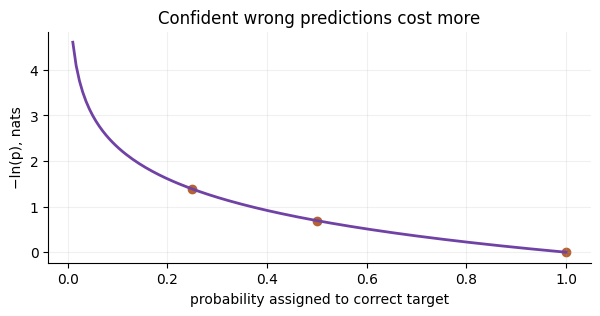

In [4]:
p=np.linspace(.01,1,150)
plt.plot(p,-np.log(p),color="#7042a6",lw=2)
for v in [.25,.5,1.]:plt.scatter([v],[-math.log(v)],color="#b56332")
plt.xlabel("probability assigned to correct target");plt.ylabel("−ln(p), nats");plt.title("Confident wrong predictions cost more");plt.show()

## Find it in the transformer

The following values were exported at full precision from the pinned Unit 1 checkpoint. Crops are for display; complete vectors are used in calculations.

Recorded input: `You taught me language; and my p`.

Reference lesson: **training-loop**.

In [5]:
#@title Recorded model fixture (included; no download) { display-mode: "form" }
recorded = json.loads('{"logits":[-6.9014668464660645,-5.996644973754883,-7.887328147888184,-7.414780616760254,-7.885478496551514,-3.1032731533050537,-7.6326422691345215,-3.265948534011841,-7.54248571395874,-15.202840805053711,-9.034098625183105,-9.057761192321777,-8.718977928161621,-4.253017425537109,-7.3833842277526855,-8.95476245880127,-14.894305229187012,-4.552713871002197,-10.069396018981934,-12.25580883026123,-8.427778244018555,-4.957304000854492,-8.789478302001953,-6.647819519042969,-2.0081562995910645,-5.152061462402344,-14.283744812011719,-2.6434991359710693,-2.970106601715088,-9.298921585083008,-1.5399258136749268,-11.352750778198242,-7.7105865478515625,-3.646576166152954,-8.153875350952148,-7.241445541381836,-8.967010498046875,-4.632282733917236,-17.961515426635742,10.185425758361816,1.824371337890625,3.3706700801849365,-0.3963257074356079,9.48599910736084,3.3263962268829346,-4.784208297729492,6.374223709106445,8.534950256347656,-4.091991901397705,3.969867706298828,9.726929664611816,3.616529941558838,4.690378665924072,9.501903533935547,6.440737724304199,2.7432503700256348,10.667499542236328,-2.0945372581481934,2.4795243740081787,8.76667308807373,0.7030054926872253,3.850490093231201,2.728739023208618,5.821852684020996,-5.201043128967285],"probs":[7.974778171160324e-09,1.9709588627847552e-08,2.975526713910881e-09,4.772978456912824e-09,2.9810369728267005e-09,3.5583846624831494e-07,3.838598772176738e-09,3.0241551485232776e-07,4.200753966898674e-09,1.9791444958588977e-12,9.452088001182801e-10,9.231053144098667e-10,1.295337503925964e-09,1.1270037703070557e-07,4.925202912176019e-09,1.023254925236472e-09,2.6944640095505346e-12,8.351588576260838e-08,3.3566327495293535e-10,3.7701342048279685e-11,1.7332043578122125e-09,5.57259660638465e-08,1.2071617039310922e-09,1.027722973390155e-08,1.0637911600497318e-06,4.586437896136886e-08,4.961760603078291e-12,5.635470756715222e-07,4.0652443544786365e-07,7.252989875361493e-10,1.6990501308100647e-06,9.301443643083829e-11,3.550767013749123e-09,2.0668053934969066e-07,2.2793147369526423e-09,5.676329184467477e-09,1.010797556766363e-09,7.712812077897979e-08,1.254296823740078e-13,0.2101171910762787,4.91249120386783e-05,0.0002305955276824534,5.331693046173314e-06,0.10440094769001007,0.00022060876653995365,6.625705140095306e-08,0.004648122005164623,0.04033380374312401,1.323908804806706e-07,0.00041983535629697144,0.13284318149089813,0.00029486711719073355,0.0008629645453765988,0.10607466101646423,0.004967801738530397,0.0001231305650435388,0.34026992321014404,9.75755938270595e-07,9.458695421926677e-05,0.05085165798664093,1.6006593796191737e-05,0.0003725923888850957,0.00012135665019741282,0.0026753824204206467,4.367199579746739e-08],"target":56}')
print("Recorded: prompter-r1; input: You taught me language; and my p")

Recorded: prompter-r1; input: You taught me language; and my p


In [6]:
z=torch.tensor(recorded["logits"])[None];target=torch.tensor([recorded["target"]]);print("last position loss for the actual next character r",F.cross_entropy(z,target).item());print("This is one position, not the validation loss or whole-batch loss.")

last position loss for the actual next character r 1.0780160427093506
This is one position, not the validation loss or whole-batch loss.


## A common trap

Pass logits directly to F.cross_entropy. Applying softmax first changes the calculation. Low training loss alone does not establish generalization.

### ✋ Your turn

If the correct character receives probability 1/4, what is its loss in natural-log units?

In [7]:
answer = None  # TODO: make a prediction, then enter your answer

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(float(answer) - math.log(4)) < 1e-6, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = math.log(4)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(float(answer) - math.log(4)) < 1e-6, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

✓ right: 1.3862943611198906


## Connect the dots

Cross-entropy averages the negative logarithm of the probability assigned to the correct next character.

Next: derivatives and backpropagation.

To explain this operation to someone else, name its inputs, calculate one output, give its PyTorch equivalent, and point to its place in the transformer.